In [1]:
import scopesim as sim
from scopesim.source.source import Source
sim.link_irdb("../..")

import numpy as np
from astropy.wcs import WCS
from astropy import units as u
import matplotlib.pyplot as plt
from synphot import SourceSpectrum

Set up the simulation in 'LSS' mode.

Note: On my 32 GB WSL Ubuntu system, O(0.001) um is the maximum resolution you can use if oversampling at all before you exceed RAM limits and the process gets killed. For best performance, run with a .py script.

In [2]:
# Set up
cmd_lss = sim.UserCommands(use_instrument="UVEX", set_modes=['lss'])

# Lower spectral bin width and resolution for the sake of time in this tutorial
cmd_lss["!SIM.spectral.spectral_bin_width"] = 1e-3
cmd_lss["!SIM.spectral.spectral_resolution"] = 3000

# Optional: you could instead restrict wavelength range and keep the higher spectral resolution
# cmd_lss["!SIM.spectral.wave_min"] = 0.20
# cmd_lss["!SIM.spectral.wave_max"] = 0.25

# Examine yaml bang strings
print(cmd_lss)

CurrSys contents:
├─OBS:
│ ├─instrument: UVEX
│ ├─modes: ['lss']
│ ├─dit: 300
│ └─ndit: 1
├─TEL:
│ ├─temperature: 0
│ └─telescope: UVEX
├─ATMO:
│ └─location: Space
├─INST:
│ ├─pixel_scale: 0.8
│ ├─plate_scale: 80
│ ├─decouple_detector_from_sky_headers: True
│ ├─fov_x0: 12600.0
│ └─fov_y0: 0.0
├─DET:
│ ├─detector: UVEX_CMOS_LSS
│ ├─image_plane_id: 0
│ ├─dit: !OBS.dit
│ ├─ndit: !OBS.ndit
│ └─gain: 1.2
└─SIM:
  ├─spectral:
  │ ├─spectral_bin_width: 0.001
  │ ├─spectral_resolution: 3000
  │ ├─wave_min: 0.115
  │ ├─wave_mid: 0.235
  │ ├─wave_max: 0.355
  │ └─wave_unit: um
  └─random:
    └─seed: 9001

SystemDict contents:
├─SIM:
│ ├─spectral:
│ │ ├─wave_min: 0.3
│ │ ├─wave_mid: 2.2
│ │ ├─wave_max: 20
│ │ ├─wave_unit: um
│ │ ├─spectral_bin_width: 0.0001
│ │ ├─spectral_resolution: 5000
│ │ ├─minimum_throughput: 1e-06
│ │ └─minimum_pixel_flux: 1
│ ├─sub_pixel:
│ │ ├─flag: False
│ │ └─fraction: 1
│ ├─random:
│ │ └─seed: None
│ ├─computing:
│ │ ├─chunk_size: 2048
│ │ ├─max_segment_size: 16777217

Print all effects and the order in which they get applied (z order).

In [3]:
opt = sim.OpticalTrain(cmd_lss)
om = opt.optics_manager
z_levels = np.arange(0, 1000, 100)
for z in z_levels:
    effs = om.get_z_order_effects(int(z))
    print(f"\nz-range {z}..{z+99}")
    for eff in effs:
        el = next(oe for oe in om.optical_elements if eff in oe.effects)
        print(f"{el.meta['name']:<20} | {eff.display_name:<20} | {eff.__class__.__name__:<20} | z_order={eff.z_order}")

py.warnings - WARNING: /home/eshread/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits

z-range 0..99
UVEX                 | ota_surface_list     | SurfaceList          | z_order=(20, 120, 520)
LSS                  | relay_optics         | SurfaceList          | z_order=(20, 120, 520)
LSS                  | surfaces             | SurfaceList          | z_order=(20, 120, 520)
LSS                  | slit_geometry        | SlitMask             | z_order=(40, 240, 340)
LSS                  | spectral_traces      | SpectralTraceList    | z_order=(70, 270, 670)
uvex_lss_detector    | LSS_Detector         | DetectorList         | z_order=(90, 290, 390, 490)

z-range 100..199
UVEX                 | ota_surf

Define the source. For this example, we will choose three stars at different positions but with the same Vega spectrum.

In [4]:
lam_array = np.arange(0.115, 0.355, 0.01)*u.um 
sp = SourceSpectrum.from_vega()

stars = Source(
    y=[-300., 0.0, 500.],          
    x=[12599.75, 12600., 12600.25],           
    ref=[0, 1, 2],           
    weight=[1.0, 1.0, 1.0], 
    spectra=[sp, sp, sp],
    lam=lam_array
)

In [5]:
# Run the simulation
opt_lss = sim.OpticalTrain(cmd_lss)
opt_lss.observe(stars, update=True)
hdulist_lss = opt_lss.readout()[0]

py.warnings - WARNING: /home/eshread/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits
py.warnings - WARNING: /home/eshread/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:211: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 Slit PSF Convolution: 100%|██████████| 256/256 [00:16<00:00, 15.34it/s]


astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /home/eshread/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat
astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 12651884 negative pixels


 LSS Detector PSF Convolution: 28160it [01:14, 375.85it/s]                           


astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
astar.scopesim.detector.detector_manager - Extracting from 2 detectors...
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8310434 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8307549 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2


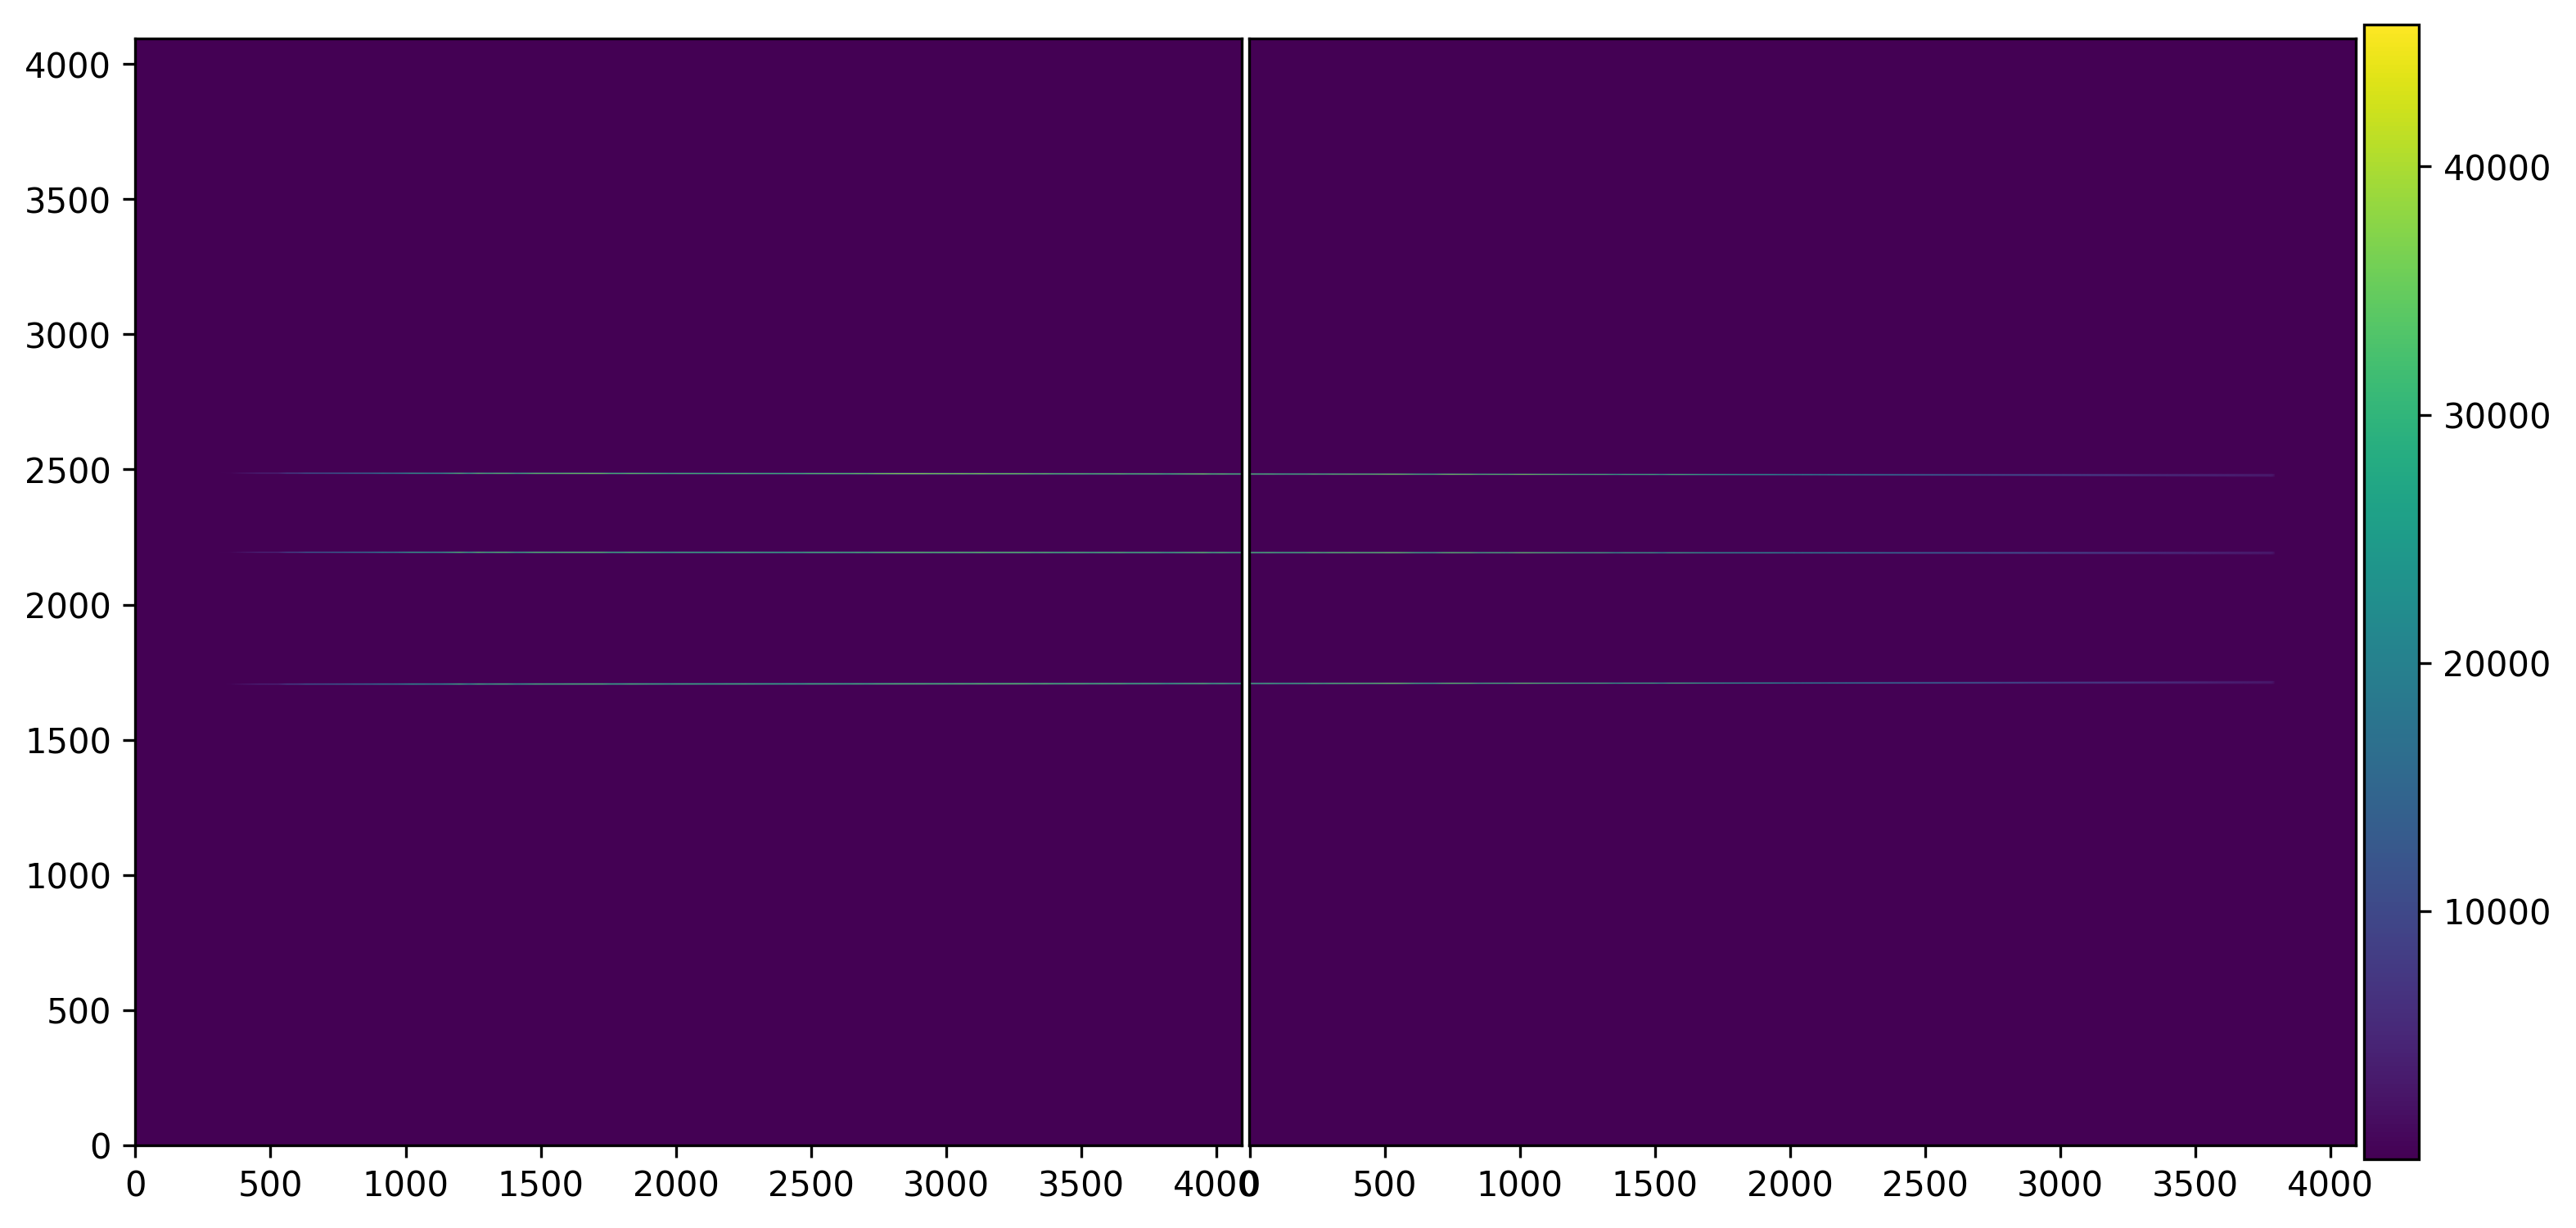

In [6]:
# Plot the output image
fig, axs = plt.subplots(ncols=3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]}, dpi=300)
ax0, ax1, cax = axs
ax0.tick_params(axis="both", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_yticks([])

im0 = ax0.imshow(hdulist_lss[1].data, origin='lower')
im1 = ax1.imshow(hdulist_lss[2].data, origin='lower')

cbar = fig.colorbar(im1, cax=cax)
plt.subplots_adjust(wspace=0.01)
plt.show()

In [7]:
# Now rectify the spectra
tracelist = opt_lss["spectral_traces"]
rectified = tracelist.rectify_traces(hdulist_lss, xi_min=-550., xi_max=550.)

astar.scopesim.effects.spectral_trace_list - Full wavelength range: 0.12 .. 0.35 um


 Traces:   0%|          | 0/1 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Rectifying UVIM_LSS_trace (0.12 .. 0.35 um)
astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /home/eshread/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat


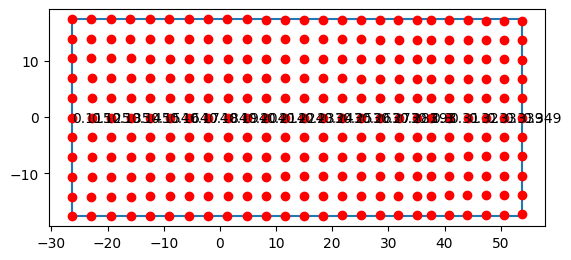

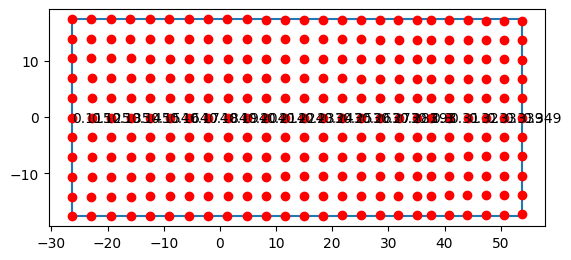

In [8]:
# plot spectral trace footprint
tracelist.plot()

[ 100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  475  476  477  478  479  480
  481  482  483  484  485  486  487  488  489  490  491  492  493  494
  495  496 1099 1100 1101 1102 1103 1104 1105 1106 1107 1108 1109 1110
 1111 1112 1113 1114 1115 1116 1117 1118 1119 1120 1121]


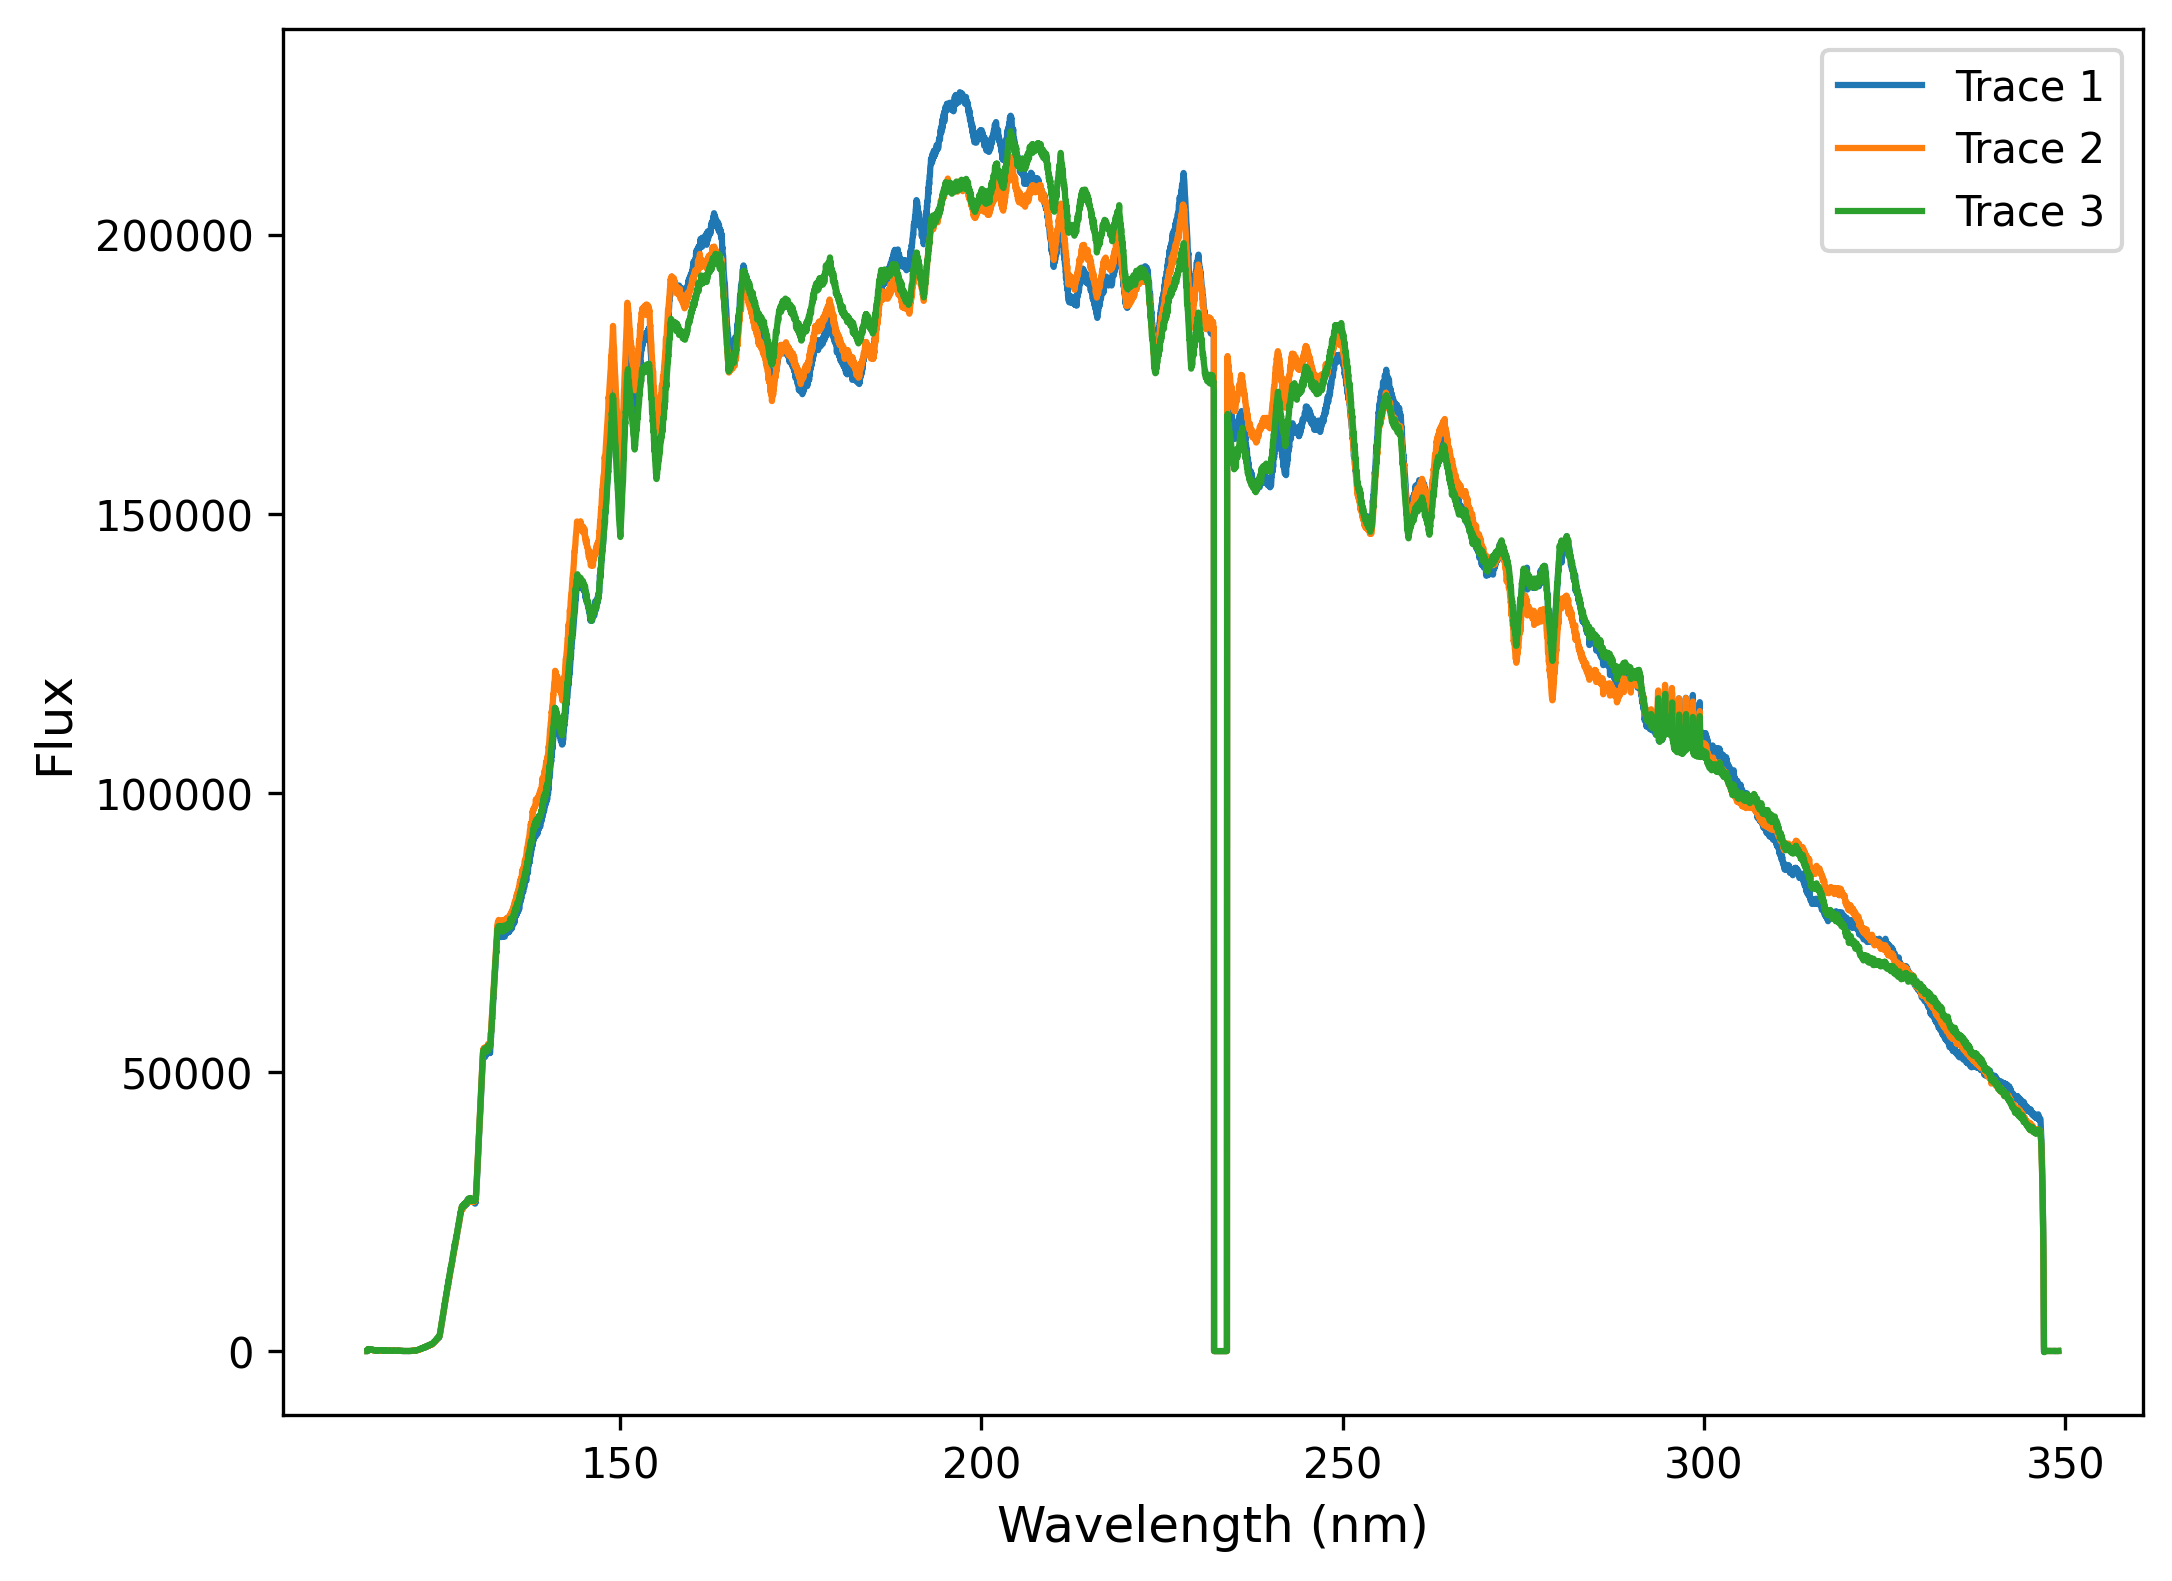

In [9]:
# Filter signal from noise manually
signal_y, signal_x = np.where(rectified[1].data > 20)

# Find the y indices of the traces
trace_indices = np.unique(signal_y)
print(trace_indices)

w = WCS(rectified[1].header)
n_lam = rectified[1].data.shape[1]
pix_x = np.arange(1, n_lam+1)
lam = w.all_pix2world(pix_x, np.ones_like(pix_x), 0)[0]
lam = np.array(lam)*10**9 # nm

# Select by eye for now
trace1 = rectified[1].data[100:122, :].sum(axis=0)
trace2 = rectified[1].data[475:497, :].sum(axis=0)
trace3 = rectified[1].data[1099:1122, :].sum(axis=0)

# Plot the 3 traces
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1), label="Trace 1")
ax.plot(lam, np.array(trace2), label="Trace 2")
ax.plot(lam, np.array(trace3), label="Trace 3")
ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Flux", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.show()